# Genome PRD v1 — 04.1 SHAP model interpretation

Explain the current 30-feature XGBoost model with SHAP values calculated on a deterministic sample of the complete out-of-time test set. SHAP values are reported on the model's raw log-odds scale: positive values increase the prediction of `rating >= 4`, while negative values decrease it.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from xgboost import XGBClassifier

here = Path.cwd().resolve()
ROOT = next(path for path in (here, *here.parents) if (path / 'src/training/prd_config.py').is_file())
sys.path.insert(0, str(ROOT))
from src.training import prd_config
from src.training.modeling import load_split

SHAP_SAMPLE_ROWS = 50_000
TOP_FEATURES = 15
RANDOM_SEED = int(prd_config.PRD_MODEL_PARAMS['random_state'])
FIGURE_DIR = ROOT / 'docs/whitepaper/figures'
TABLE_DIR = ROOT / 'docs/whitepaper/tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
print('SHAP version:', shap.__version__)

SHAP version: 0.52.0


## Load the model and sample the test set

The temporal test partition is loaded through the same executable contract used by model evaluation. A fixed seed selects 50,000 rows without replacement, making the interpretation sample reproducible.

In [2]:
model = XGBClassifier()
model.load_model(prd_config.PRD_ARTIFACT_PATH)
ratings = pd.read_parquet(
    prd_config.RATINGS_SOURCE_PATH, columns=['rating']
)["rating"].to_numpy(dtype=np.float32, copy=False)
test_x, test_y, _ = load_split(
    prd_config.FEATURE_ARTIFACT_PATH,
    ratings,
    'test',
    prd_config.PRD_FEATURES,
)
sample_size = min(SHAP_SAMPLE_ROWS, len(test_y))
selected = np.sort(
    np.random.default_rng(RANDOM_SEED).choice(len(test_y), sample_size, replace=False)
)
sample_features = pd.DataFrame(
    test_x[selected], columns=prd_config.PRD_FEATURES
)
sample_labels = test_y[selected]
del test_x
print('Test rows:', len(test_y))
print('SHAP sample rows:', len(sample_features))
print('Test prevalence:', f'{test_y.mean():.4%}')
print('Sample prevalence:', f'{sample_labels.mean():.4%}')

Test rows: 846774
SHAP sample rows: 50000
Test prevalence: 50.1728%
Sample prevalence: 49.9760%


## Calculate and verify SHAP values

For this binary tree model, `TreeExplainer` returns additive contributions on the raw margin scale. The verification below checks that the base value plus all 30 SHAP contributions reconstructs XGBoost's raw margin for every sampled row.

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(sample_features, check_additivity=False)
raw_margin = model.get_booster().predict(
    xgb.DMatrix(sample_features), output_margin=True
)
reconstructed_margin = (
    np.asarray(shap_values.base_values)
    + np.asarray(shap_values.values).sum(axis=1)
)
max_additivity_error = float(
    np.max(np.abs(raw_margin - reconstructed_margin))
)
assert shap_values.values.shape == (sample_size, len(prd_config.PRD_FEATURES))
assert max_additivity_error < 1e-4
print('SHAP matrix shape:', shap_values.values.shape)
print('Maximum raw-margin reconstruction error:', max_additivity_error)

SHAP matrix shape: (50000, 30)
Maximum raw-margin reconstruction error: 1.0013580322265625e-05


## Global SHAP importance

Mean absolute SHAP summarizes how much each variable changes the model's raw prediction on average. It measures influence, not direction or causality.

In [4]:
shap_importance = (
    pd.DataFrame(
        {
            'feature': prd_config.PRD_FEATURES,
            'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
            'mean_shap': shap_values.values.mean(axis=0),
        }
    )
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
shap_importance.index = np.arange(1, len(shap_importance) + 1)
shap_importance.index.name = 'rank'
display(shap_importance.head(TOP_FEATURES).style.format('{:.4f}', subset=['mean_abs_shap', 'mean_shap']))

latex_rows = [
    rf'{rank} & \path{{{row.feature}}} & {row.mean_abs_shap:.3f} \\'
    for rank, row in shap_importance.head(TOP_FEATURES).iterrows()
]
shap_table_lines = [
    r'\begin{table}[htbp]',
    r'\centering\small',
    r'\begin{tabular}{@{}rlr@{}}',
    r'\toprule',
    r'Rank & Feature & Mean $|\mathrm{SHAP}|$ \\',
    r'\midrule',
    *latex_rows,
    r'\bottomrule',
    r'\end{tabular}',
    rf'\caption{{Global SHAP importance on a deterministic sample of {sample_size:,} out-of-time test events. Values are mean absolute contributions to the raw log-odds margin.}}',
    r'\label{tab:shap-global-importance}',
    r'\end{table}',
]
shap_table_path = TABLE_DIR / 'shap_importance.tex'
shap_table_path.write_text('\n'.join(shap_table_lines) + '\n')
print('Saved:', shap_table_path.relative_to(ROOT))

,feature,mean_abs_shap,mean_shap
rank,,,
1,genome_preference_margin,0.5890,-0.0285
2,user_mean_rating,0.5248,0.1124
3,movie_mean_rating,0.2012,0.0171
4,movie_rating_avg_60d,0.1744,0.0293
5,user_rating_count,0.1661,-0.0411
6,user_target_genre_mean_rating,0.1530,0.0265
7,genome_nearest_liked_similarity,0.1418,0.0461
8,user_rating_std_pop,0.1270,-0.0340
9,genome_user_positive_cosine,0.1157,0.0009


Saved: docs/whitepaper/tables/shap_importance.tex


## Global importance plot

The bar chart ranks variables by mean absolute SHAP value.

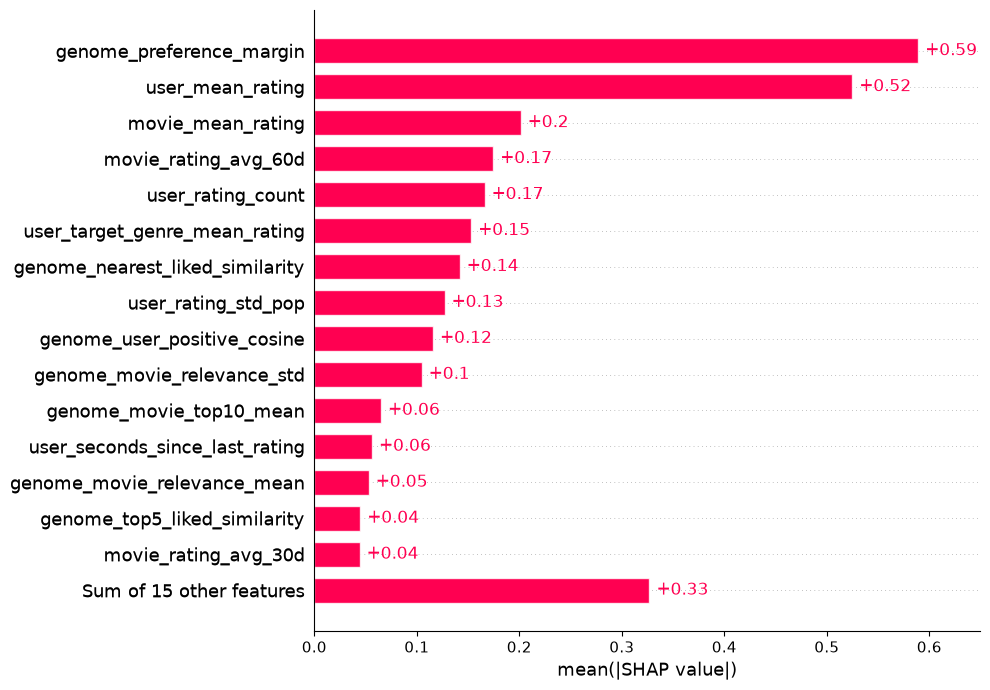

Saved: docs/whitepaper/figures/shap_global_importance.png


In [5]:
shap.plots.bar(shap_values, max_display=TOP_FEATURES + 1, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 7)
plt.tight_layout()
importance_figure_path = FIGURE_DIR / 'shap_global_importance.png'
fig.savefig(importance_figure_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', importance_figure_path.relative_to(ROOT))

## SHAP beeswarm

Each point represents one sampled test event. Horizontal position is the SHAP contribution, while color represents the original feature value. This plot adds direction and distribution to the global ranking.

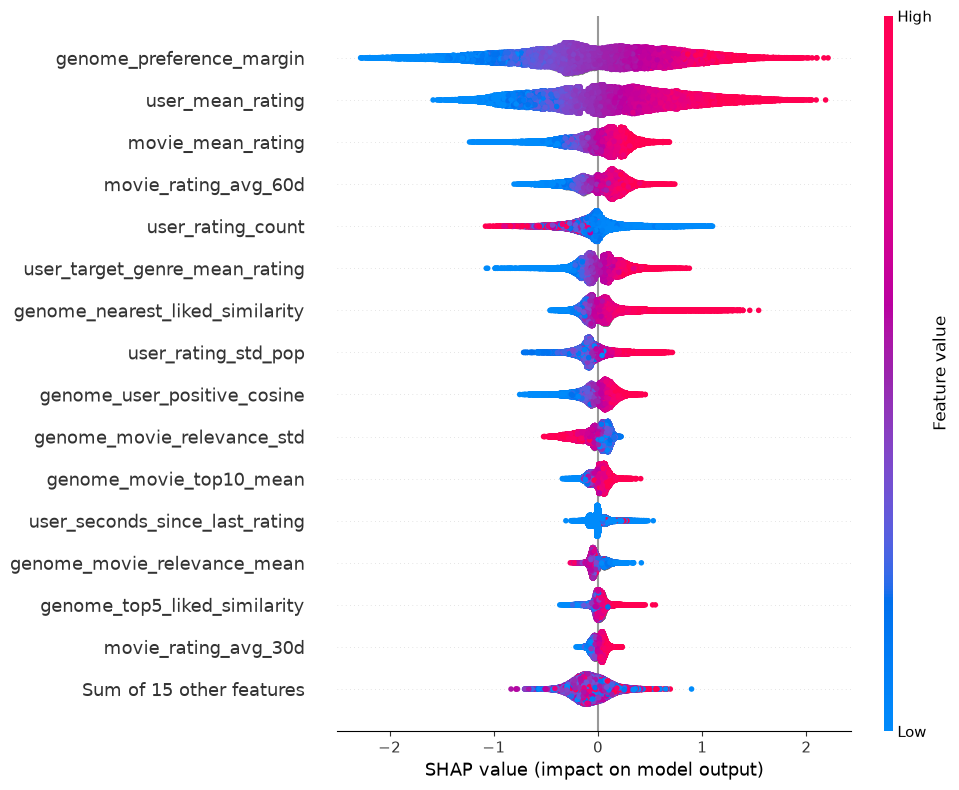

Saved: docs/whitepaper/figures/shap_beeswarm.png


In [6]:
shap.plots.beeswarm(
    shap_values, max_display=TOP_FEATURES + 1, show=False, plot_size=(10, 8)
)
fig = plt.gcf()
plt.tight_layout()
beeswarm_figure_path = FIGURE_DIR / 'shap_beeswarm.png'
fig.savefig(beeswarm_figure_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', beeswarm_figure_path.relative_to(ROOT))

## Interpretation limits

SHAP explains how this fitted model uses its inputs on the sampled test events. It does not establish that a variable causes a high rating. Correlated predictors can divide or redistribute attribution, and the results summarize this model, feature contract, test period, and deterministic sample.